In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import re
import itertools
from tqdm import tqdm
from collections import defaultdict
import scipy

import matplotlib
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))
preprocessing_utils = lazy_import("preprocessing_utils",os.path.join(utils_dir, "preprocessing_utils.py"))

from general_utils import ismember, grep, grep_exclude, grep_indexes, read_object, write_object
from anndata_utils import marker_genes_for_cell_group, zscore_with_subset, get_gene, get_genes, annotate_groups, random_adata_subset, query_region, filter_coordinates
from thresholding_functions import threshold_otsu, threshold_triangle
from preprocessing_utils import consolidate_var_names, norm_log_transform


### Read all datasets

#### Read scRNA-seq data

In [ ]:
input_path = "../../transcriptomics/data/Reyes_injury_SUBSET_all__annotated.h5ad"
adata = sc.read_h5ad(input_path)

#### Consolidate ensembl names and get genomic coordinates for each gene symbol

This step is important because the data was mapped with SEQC using an old ensembl gft file, losing the original gene symbol. Many gene symbols have been updated since then, and thus, I would lose information from these genes if I intersected them with the most current ensembl annotation. 

In [ ]:
ensembl_annotation = pd.read_csv('../../transcriptomics/support/Mus_musculus.GRCm38.102.filtered.txt', sep = '\t')
ensembl_annotation['gene_name'] = [x.upper() for x in ensembl_annotation['gene_name']]

In [ ]:
# Prioritize protein coding and lncRNAs, excluding non-canonical chromosomes
ensembl_rescue_table = pd.read_csv('../../transcriptomics/support/Mus_musculus.GRCm38.all_non_redundant.transcript.update_symbol.txt', sep = '\t')
valid_gene_types = ['protein_coding', 'lncRNA', 'IG_C_gene', 'Mt_rRNA','Mt_tRNA', 'TEC', 'TR_C_gene', 'TR_D_gene', 'TR_J_gene']
valid_chromosomes = ['MT', '10', '16', '13', '2', 'X', '7', '1', '9', '18', '3', '4', '6', '14', '8', '5', '12', '15', '11', '19', '17', 'Y']
ensembl_rescue_table = ensembl_rescue_table.loc[ismember(ensembl_rescue_table['Chromosome.scaffold.name'], valid_chromosomes)[1],:].copy()
ensembl_rescue_table = ensembl_rescue_table.loc[ismember(ensembl_rescue_table['Gene.type'], valid_gene_types)[1],:].copy()

# Leverage previous mapping from gene symbols in Pe'er lab older datasets to new gene symbols based on historical correspondence between gene ids
peerlab_name = np.array([x.upper() for x in ensembl_rescue_table['mm38_peerlab_name']])
gene_name = np.array([x.upper() for x in ensembl_rescue_table['Gene.name']])
gene_rescue_map = defaultdict(list)
for source in np.unique(peerlab_name):
    gene_rescue_map[source] = list(np.unique(gene_name[peerlab_name == source]))

# For genes that map into multiple ones, check if one of these genes preserve the symbol in the current dataset
source_names = np.array(list(gene_rescue_map.keys()))
num_targets = np.array([len(gene_rescue_map[x]) for x in gene_rescue_map.keys()])

ambiguous = source_names[num_targets > 1]
for my_gene in ambiguous:
    if my_gene in gene_rescue_map[my_gene]:
        gene_rescue_map[my_gene] = [my_gene]

# There was a single gene that had two new symbols and I manually added this
gene_rescue_map['SSSCA1'] = ['ZNRD2']

# Verify that all symbols only map to one symbol
source_names = np.array(list(gene_rescue_map.keys()))
num_targets = np.array([len(gene_rescue_map[x]) for x in gene_rescue_map.keys()])
display(pd.Series(num_targets).value_counts())

1    25506
Name: count, dtype: int64

Now check whether old symbols that are absent in dataset can be rescued by updating them

In [ ]:
in_ensembl_table = ismember(adata.var_names, ensembl_annotation['gene_name'])[1]
invalid_genes = adata.var_names[np.logical_not(in_ensembl_table)].to_numpy()
in_peerlab_gene_names = ismember(adata.var_names, source_names)[1]

genes_with_meaningful_names = grep_exclude(".", grep_exclude("RIK", grep_exclude("GM", invalid_genes)))
all_gene_symbols = adata.var_names.to_numpy().copy()
genes_to_rescue = np.logical_and(in_peerlab_gene_names, np.logical_not(in_ensembl_table))
all_gene_symbols[genes_to_rescue] = np.array([gene_rescue_map[x][0] for x in all_gene_symbols[genes_to_rescue]])
adata.var['original_symbol'] = adata.var_names.copy()
adata.var_names = all_gene_symbols.copy()

in_ensembl_table = ismember(adata.var_names, ensembl_annotation['gene_name'])[1]
invalid_genes = adata.var_names[np.logical_not(in_ensembl_table)].to_numpy()
in_peerlab_gene_names = ismember(adata.var_names, source_names)[1]
still_absent = grep_exclude(".", grep_exclude("RIK", grep_exclude("GM", invalid_genes)))

genes_with_meaningful_names[np.logical_not(ismember(genes_with_meaningful_names, still_absent)[1])]

gene_freq = adata.var_names.value_counts()
repeated_symbols = gene_freq[gene_freq == 2].index.to_numpy()

In [ ]:
ensembl_rescue_table.loc[ensembl_rescue_table['mm38_peerlab_name'] == 'Gm3898']

,Gene.stable.ID,Transcript.stable.ID,Chromosome.scaffold.name,Gene.start..bp.,Gene.end..bp.,Transcript.start..bp.,Transcript.end..bp.,Transcription.start.site..TSS.,Transcript.length..including.UTRs.and.CDS.,Strand,Gene.name,Gene.type,source,transcript_present_in_mm38_peerlab,gene_present_in_mm38_peerlab,mm38_peerlab_name
10503,ENSMUSG00000032012,ENSMUST00000216905,9,43743984,43832658,43820947,43831400,43820947,328,1,Nectin1,protein_coding,Mus_musculus.GRCm38p6.102.biomart.txt.gz,True,True,Gm3898
10504,ENSMUSG00000032012,ENSMUST00000180221,9,43743984,43832658,43829831,43832658,43829831,613,1,Nectin1,protein_coding,Mus_musculus.GRCm38p6.102.biomart.txt.gz,True,True,Gm3898


In [ ]:
# The code below can be used to identify multimapped genes, verifying that they are correctly assigned according to the ensembl annotation archive
#adata.var['original_symbol'][ismember(adata.var_names, repeated_symbols)[1]].reset_index().sort_values(by='index')

In [ ]:
len(np.unique(adata.var_names))

20120

In [ ]:
original_symbol_map = {x:y for x,y in zip(adata.var['original_symbol'], adata.var_names)}

Consolidated repeated gene symbols, and renormalize dataset

In [ ]:
adata.X = adata.layers['cellbender'].copy()
adata_consolidated = consolidate_var_names(adata, return_sparse=True)
adata_consolidated.layers['cellbender'] = adata_consolidated.X.copy()
adata = adata_consolidated.copy()
adata = norm_log_transform(adata, adata.obs['size_factor'], [])

Normalizing data


/data1/lowes/reyesj3/miniconda3/envs/scanpy/lib/python3.11/site-packages/scipy/sparse/_construct.py:178: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if len(diagonals) == 0 or isscalarlike(diagonals[0]):


Log transform with pseudocount 1


#### Identify ranges for p53 motif search per gene symbol consensus tss

In [ ]:
adata = adata[:,ismember(adata.var_names, ensembl_annotation['gene_name'])[1]].copy()

In [ ]:
min_start = ensembl_annotation.loc[:,["gene_id", "strand", "start"]].groupby(["gene_id", "strand"]).agg(lambda x: np.min(x))
max_start = ensembl_annotation.loc[:,["gene_id", "strand", "start"]].groupby(["gene_id", "strand"]).agg(lambda x: np.max(x))
min_end = ensembl_annotation.loc[:,["gene_id", "strand", "end"]].groupby(["gene_id", "strand"]).agg(lambda x: np.min(x))
max_end = ensembl_annotation.loc[:,["gene_id", "strand", "end"]].groupby(["gene_id", "strand"]).agg(lambda x: np.max(x))

biotype = ensembl_annotation.loc[:,["gene_id", "transcript_biotype"]].groupby(["gene_id"]).agg(lambda x: np.unique(x)[0])

symbol_to_gene_id = ensembl_annotation.loc[:,["gene_id", "symbol"]].groupby(["symbol"]).agg(lambda x: np.unique(x))
symbol_to_gene_id_number = ensembl_annotation.loc[:,["gene_id", "symbol"]].groupby(["symbol"]).agg(lambda x: len(np.unique(x)))
multimapped = symbol_to_gene_id[symbol_to_gene_id_number['gene_id'] > 1]

In [ ]:
multimapped

,gene_id
symbol,


In [ ]:
ensembl_annotation.loc[:,["symbol", "strand"]].groupby(["symbol"]).agg(lambda x: len(np.unique(x))).value_counts().value_counts()

count
27439    1
Name: count, dtype: int64

In [ ]:
ensembl_annotation.to_csv(os.path.join("../support/", "ensembl_annotation_local_filtered.csv"))

Aggregate transcription start by gene symbol. I identify the final TSS of each symbol as the median of all isoforms that have the same symbol. This ensures that I'm working with the most common start site.

In [ ]:
min_start = ensembl_annotation.loc[:,["symbol", "start"]].groupby(["symbol"]).agg(lambda x: np.min(x))
max_start = ensembl_annotation.loc[:,["symbol", "start"]].groupby(["symbol"]).agg(lambda x: np.max(x))
min_end = ensembl_annotation.loc[:,["symbol", "end"]].groupby(["symbol"]).agg(lambda x: np.min(x))
max_end = ensembl_annotation.loc[:,["symbol", "end"]].groupby(["symbol"]).agg(lambda x: np.max(x))

biotype = ensembl_annotation.loc[:,["symbol", "transcript_biotype"]].groupby(["symbol"]).agg(lambda x: np.unique(x))
median_start = ensembl_annotation.loc[:,["symbol", "start"]].groupby(["symbol"]).agg(lambda x: int(np.median(x)))
median_end = ensembl_annotation.loc[:,["symbol", "end"]].groupby(["symbol"]).agg(lambda x: int(np.median(x)))
chromosome = ensembl_annotation.loc[:,["symbol", "chr"]].groupby(["symbol"]).agg(lambda x: np.unique(x)[0])
strand = ensembl_annotation.loc[:,["symbol", "strand"]].groupby(["symbol"]).agg(lambda x: np.unique(x)[0])

start_difference = max_start - min_start

In [ ]:
window_size = 20000
median_start['tss'] = [x_start if x_strand == "+" else x_end for x_start,x_end,x_strand in zip(median_start['start'], median_end['end'], strand['strand'])]
median_start['seqnames'] = chromosome
median_start['window_start'] = median_start['tss'] - window_size
median_start['window_end'] = median_start['tss'] + window_size


In [ ]:
median_start

,start,tss,seqnames,window_start,window_end
symbol,,,,,
0610006L08Rik,74823615,74853810,chr7,74833810,74873810
0610009B22Rik,51685386,51688874,chr11,51668874,51708874
0610010F05Rik,23573251,23629027,chr11,23609027,23649027
0610010K14Rik,70235404,70237804,chr11,70217804,70257804
0610012G03Rik,31947050,31948494,chr16,31928494,31968494
...,...,...,...,...,...
Zyx,42350039,42350039,chr6,42330039,42370039
Zzef1,72796254,72796254,chr11,72776254,72816254
Zzz3,152396003,152396003,chr3,152376003,152416003


In [ ]:
median_start['original_symbol'] = median_start.index.to_numpy()
median_start.index = [x.upper() for x in median_start.index]

In [ ]:
adata.var['chr'] = median_start.loc[adata.var_names, "seqnames"]
adata.var['tss'] = median_start.loc[adata.var_names, "tss"]
adata.var['window_start'] = median_start.loc[adata.var_names, "window_start"]
adata.var['window_end'] = median_start.loc[adata.var_names, "window_end"]

#### Read motif data

In [ ]:
p53_motif = pd.read_csv("../preprocessed/step4_p53_program/multiome_PP20251110_p53_motif_annotated_v2.csv.gz", index_col = 0)
p53_motif_metadata = pd.DataFrame([re.findall('(chr.*?):(\d+)-(\d+)', x)[0] for x in p53_motif['motif_id']], index = p53_motif.index, columns = ['seqnames', 'start', 'end'])
p53_motif = pd.concat([p53_motif, p53_motif_metadata], axis = 1)
p53_motif['start'] = p53_motif['start'].astype(np.uint64)
p53_motif['end'] = p53_motif['end'].astype(np.uint64)

In [ ]:
p53_motif = p53_motif.loc[p53_motif['progenitor_accessible'],:].copy()

Map motifs to tss windows, as defined above

In [ ]:
result_gene = []
result_motif = []
for i, my_gene in enumerate(adata.var_names):
    current_vars = adata.var.loc[my_gene, ['chr', 'window_start', 'window_end']]
    chr_filter = p53_motif['seqnames'] == current_vars['chr']
    position_filter = (p53_motif['start'].to_numpy() > current_vars['window_start']) & (p53_motif['end'].to_numpy() < current_vars['window_end'])
    valid_motifs = np.logical_and(chr_filter, position_filter)
    if(np.sum(valid_motifs) > 0):
        result_gene += [i] * np.sum(valid_motifs)
        result_motif += list(np.where(valid_motifs)[0])

In [ ]:
overlaps = pd.DataFrame({'gene_index': result_gene, 'motif_index': result_motif})
for my_column in p53_motif.columns:
    overlaps[my_column] = p53_motif.iloc[overlaps['motif_index'],:][my_column].to_numpy()
overlaps['gene_symbol'] = adata.var_names[overlaps['gene_index']].to_numpy()
overlaps.loc[overlaps['gene_symbol'] == 'AREG',:]

,gene_index,motif_index,motif_id,coverage_progenitor,coverage_gastric,progenitor_specific,gastric_specific,p53_ChIP_200,progenitor_accessible,gastric_accessible,within_peaks,motif_type,seqnames,start,end,gene_symbol
494,1649,3997,chr5:91149772-91149791,0.259794,0.094178,False,False,False,True,False,True,canonical,chr5,91149772,91149791,AREG


In [ ]:
len(overlaps['gene_index'].unique())

3853

Write metadata

In [ ]:
p53_motif.to_csv("../preprocessed/step4_p53_program/Reyes_multiome_p53_motif_withMetadata_v2.csv")

In [ ]:
overlaps.to_csv("../preprocessed/step4_p53_program/Reyes_multiome_p53_motif_gene_symbol_mapping_v2.csv")

#### Read differential gene expression results

Progenitor shp53 vs Progenitor shRen

In [ ]:
preprocessing_path = "../../transcriptomics/differential_expression/injury_shp53/"

np.sort(os.listdir(preprocessing_path))

array(['cell_type_genotype_replicate_id',
       'cell_type_refined_progenitor_pheno_genotype_replicate_id',
       'progenitor_all_genotype_replicate_id',
       'progenitor_shared_pheno_30_genotype_replicate_id'], dtype='<U56')

In [ ]:
deg_strategy = "progenitor_shared_pheno_30_genotype_replicate_id"
deg_path = os.path.join(preprocessing_path, deg_strategy)
np.sort(os.listdir(deg_path))
deg = pd.read_csv(os.path.join(deg_path, "DESEQ20260104_FILTER__progenitor_shared_pheno_30__True__genotype__shp53_shRen__CONTRAST__shp53_vs_shRen.csv"), index_col = 0)

In [ ]:
LOG_FC_THRESHOLD = -0.5
suffix = "published"
PADJ_THRESHOLD = 0.005

fold_change_filter = deg['log2FoldChange'] < LOG_FC_THRESHOLD
pval_filter = deg['padj'] < PADJ_THRESHOLD
shp53_down = deg.loc[np.logical_and(fold_change_filter, pval_filter),:].index.to_numpy()

len(shp53_down)

301

shRen Progenitor vs shRen gastric

In [ ]:
np.sort(os.listdir(preprocessing_path))

array(['cell_type_genotype_replicate_id',
       'cell_type_refined_progenitor_pheno_genotype_replicate_id',
       'progenitor_all_genotype_replicate_id',
       'progenitor_shared_pheno_30_genotype_replicate_id'], dtype='<U56')

In [ ]:
deg_strategy = "cell_type_refined_progenitor_pheno_genotype_replicate_id"
deg_path = os.path.join(preprocessing_path, deg_strategy)
np.sort(os.listdir(deg_path))
deg = pd.read_csv(os.path.join(deg_path, "DESEQ20250426_FILTER__cell_type_refined_progenitor_pheno__progenitor1_gastric__genotype__shRen__CONTRAST__gastric_vs_progenitor1.csv"), index_col = 0)

In [ ]:
PADJ_THRESHOLD = 0.005

fold_change_filter = deg['log2FoldChange'] < LOG_FC_THRESHOLD
pval_filter = deg['padj'] < PADJ_THRESHOLD
progenitor_up = deg.loc[np.logical_and(fold_change_filter, pval_filter),:].index.to_numpy()

len(progenitor_up)

2090

Read other signatures

In [ ]:
h2m = pd.read_csv("../support/Biomart_h2m_conversion.csv", index_col = 0)

In [ ]:
h2m

,external_gene_name,mmusculus_homolog_associated_gene_name
5,MT-ND1,mt-Nd1
9,MT-ND2,mt-Nd2
15,MT-CO1,mt-Co1
18,MT-CO2,mt-Co2
20,MT-ATP8,mt-Atp8
...,...,...
48643,JMJD4,Jmjd4
48644,TNFRSF14,Tnfrsf10b
48645,TNFRSF14,Tnfrsf14
48646,DAP3,Dap3


In [ ]:
def toupper(my_list):
    return(np.array([str(x).upper() for x in my_list]))

def convert_to_mouse(gene_list):
    converted_list = toupper(np.unique(h2m['mmusculus_homolog_associated_gene_name'][ismember(h2m['external_gene_name'], gene_list)[1]]))
    return(converted_list)

general_signatures = '../../transcriptomics/signatures/'
lambert_p63_chip = convert_to_mouse(pd.read_csv(os.path.join(general_signatures, 'Lambert_p63regulated_RNAChIP.txt'), sep = "\t")['gene_id'].to_numpy())
lambert_p63_gex = convert_to_mouse(pd.read_csv(os.path.join(general_signatures, 'Lambert_p63KO_DOWN_log2fc1.txt'), sep = "\t")['gene_id'].to_numpy())
lambert_p63_ITGB4hi = convert_to_mouse(pd.read_csv(os.path.join(general_signatures, 'Lambert_p63_ITGB4hi.txt'), sep = "\t")['gene_id'].to_numpy())
Allen2014_p53 = convert_to_mouse(pd.read_csv(os.path.join(general_signatures, 'Allen2014_p53GROseq.txt'), sep = "\t")['gene_id'].to_numpy())

p53_targets_attardi = toupper(pd.read_csv(os.path.join(general_signatures, 'Kaiser_Boutelle_Attardi_p53_targets.txt'), sep = "\t")['gene_id'].to_numpy())
p53_targets_lozano = toupper(pd.read_csv(os.path.join(general_signatures, 'Moyer_Lozano_p53_core_PMID_32900967.txt'), sep = "\t")['gene_id'].to_numpy())
p53_targets_andrysik = toupper(pd.read_csv(os.path.join(general_signatures, 'Andrysik_p53_core_program_PMID_28904012_mouse_converted.txt'), sep = "\t")['gene_id'].to_numpy())

BiegingRolett_p53_TSAG_bound = toupper(pd.read_csv(os.path.join(general_signatures, 'BiegingRolett_p53_TSAG_bound.txt'), sep = "\t")['gene_id'].to_numpy())
p53_restoration_pancreas = toupper(pd.read_csv(os.path.join(general_signatures, 'LOH_geneSignatures_p53Reactivation_UP.txt'), sep = "\t")['gene_id'].to_numpy())
p53_UP_RNAChIP = toupper(pd.read_csv(os.path.join(general_signatures, 'KenzelmannBroz_TableS4_RNAChIP_p53_DNAdamage_UP.txt'), sep = "\t")['gene_id'].to_numpy())

fisher_p53 = convert_to_mouse(pd.read_csv(os.path.join(general_signatures, 'FisherOncogeneTableS3_extended.txt'), sep = "\t")['gene_id'].to_numpy())
riley_p53 = convert_to_mouse(pd.read_csv(os.path.join(general_signatures, 'Riley2008_p53Targets.txt'), sep = "\t")['gene_id'].to_numpy())


#### Prepare p53 downregulated adata

In [ ]:
new_symbols = [original_symbol_map[x] for x in shp53_down]
adata_p53 = adata[:, ismember(adata.var_names, new_symbols)[1]].copy()

In [ ]:
adata_p53.var['lambert_p53_chip'] = ismember(adata_p53.var_names, lambert_p63_chip)[1]
adata_p53.var['lambert_p63_gex'] = ismember(adata_p53.var_names, lambert_p63_gex)[1]
adata_p53.var['lambert_p63_ITGB4hi'] = ismember(adata_p53.var_names, lambert_p63_ITGB4hi)[1]
adata_p53.var['Allen2014_p53'] = ismember(adata_p53.var_names, Allen2014_p53)[1]
adata_p53.var['p53_targets_andrysik'] = ismember(adata_p53.var_names, p53_targets_andrysik)[1]
adata_p53.var['p53_targets_attardi'] = ismember(adata_p53.var_names, p53_targets_attardi)[1]
adata_p53.var['BiegingRolett_p53_TSAG_bound'] = ismember(adata_p53.var_names, BiegingRolett_p53_TSAG_bound)[1]
adata_p53.var['p53_UP_RNAChIP'] = ismember(adata_p53.var_names, p53_UP_RNAChIP)[1]
adata_p53.var['p53_restoration_pancreas'] = ismember(adata_p53.var_names, p53_restoration_pancreas)[1]
adata_p53.var['fisher_p53'] = ismember(adata_p53.var_names, fisher_p53)[1]
adata_p53.var['riley_p53'] = ismember(adata_p53.var_names, riley_p53)[1]
adata_p53.var['p53_targets_lozano'] = ismember(adata_p53.var_names, p53_targets_lozano)[1]
adata_p53.var['previously_reported'] = (adata_p53.var['Allen2014_p53']) | (adata_p53.var['p53_targets_lozano']) | \
    (adata_p53.var['p53_targets_attardi']) | (adata_p53.var['BiegingRolett_p53_TSAG_bound']) | \
    (adata_p53.var['fisher_p53']) | (adata_p53.var['riley_p53']) | (adata_p53.var['p53_UP_RNAChIP']) | \
    (adata_p53.var['p53_targets_andrysik'])

In [ ]:
num_canonical = overlaps.loc[overlaps['motif_type'] == 'canonical', ['gene_symbol', 'motif_type']].groupby('gene_symbol').agg('count')
num_noncanonical = overlaps.loc[overlaps['motif_type'] == 'noncanonical', ['gene_symbol', 'motif_type']].groupby('gene_symbol').agg('count')
num_bound = overlaps.loc[overlaps['p53_ChIP_200'], ['gene_symbol', 'motif_type']].groupby('gene_symbol').agg('count')

In [ ]:
adata_p53.var['with_canonical_motif'] = ismember(adata_p53.var_names, num_canonical.index)[1]
adata_p53.var['with_noncanonical_motif'] = ismember(adata_p53.var_names, num_noncanonical.index)[1]
adata_p53.var['with_bound_motif'] = ismember(adata_p53.var_names, num_bound.index)[1]
adata_p53.var['with_bound_motif_public'] = adata_p53.var['p53_UP_RNAChIP']
adata_p53.var['progenitor_up'] = ismember(adata_p53.var_names, progenitor_up)[1]
adata_p53.var['with_motif'] = (adata_p53.var['with_canonical_motif']) | (adata_p53.var['with_noncanonical_motif'])


### Make heatmap

In [ ]:
adata_p53

AnnData object with n_obs × n_vars = 25907 × 298
    obs: 'hash_id', 'original_filename', 'folder', 'prefix', 'mouse_genotype', 'treatment', 'timepoint', 'genotype', 'dox', 'condition', 'replicate_number', 'barcode', 'unclear', 'inferred_doublet', 'hash_doublet', 'cluster_doublet', 'immune_stroma', 'batch', 'percent_mito', 'percent_ribo', 'replicate_id', 'log_lib_size_raw_all', 'log_lib_size_raw_noExcluded', 'log_detected_raw_all', 'log_detected_raw_noExcluded', 'log_lib_size_cellbender_all', 'log_lib_size_cellbender_noExcluded', 'log_detected_cellbender_all', 'log_detected_cellbender_noExcluded', 'n_counts', 'pheno_30', 'pheno_10', 'doublet_summary', 'consensus_doublet', 'excluded', 'pheno_5', 'GFP_positive', 'condition_id', 'size_factor', 'size_factor_corrected', 'DC_gastric_progenitor', 'DC_progenitor1_progenitor2', 'cell_type', 'cell_type_refined_progenitor_pheno', 'progenitor_shared_pheno_30', 'progenitor_all', 'DC3_progenitor2', 'DC9_progenitor2_shp53', 'DC9_progenitor2', 'cell_t

In [ ]:
def annotate_groups(adata_sub, grouping):
    adata_sub.obs['group_id'] = ['_'.join(adata_sub.obs[grouping].iloc[i,:].to_list()) for i in range(adata_sub.n_obs)]
    group_counts = adata_sub.obs['group_id'].value_counts()
    adata_sub.obs['group_id'] = [x + "_(n = " + str(group_counts.loc[x]) + ")" for x in adata_sub.obs['group_id']]


In [ ]:
cell_type_filter = ismember(adata_p53.obs['progenitor_shared_pheno_30'], [True])[1]
batch_filter = adata_p53.obs['batch'] == 3

adata_sub = adata_p53[cell_type_filter,:].copy()


In [ ]:
grouping = ["genotype", "replicate_id"]
annotate_groups(adata_sub, grouping)

adata_sub = adata_sub[adata_sub.obs['hash_id'] != "undefined",:].copy()
adata_sub.layers['zscore'] = adata_sub.X.copy()
sc.pp.scale(adata_sub, layer = 'zscore')

current_df = pd.DataFrame(adata_sub.layers['zscore'])
current_df.index = adata_sub.obs_names
current_df.columns = adata_sub.var_names
current_df['group_id'] = adata_sub.obs['group_id'].to_numpy()
current_df = current_df.groupby(['group_id']).agg('mean')

/data1/lowes/reyesj3/miniconda3/envs/scanpy/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
adata_summary = sc.AnnData(current_df)
metadata = pd.DataFrame([re.split('_', x) for x in adata_summary.obs_names], index = adata_summary.obs_names, columns = ['genotype1', 'batch', 'condition', 'treatment', 'timepoint', 'genotype', 'batch_number', 'hash_id', 'ncells'])
adata_summary.obs = metadata.copy()
adata_summary.var = adata_p53[:,adata_summary.var_names].var.copy()
adata_summary.var

adata_summary = adata_summary[np.argsort(adata_summary.obs['batch'], kind = 'mergesort').to_numpy(),:].copy()
adata_summary = adata_summary[np.argsort(adata_summary.obs['genotype'], kind = 'mergesort').to_numpy(),:].copy()

gene_ordering = np.argsort(np.ravel(adata_summary[adata_summary.obs['genotype'] == 'shRen',:].X.mean(axis=0)), kind = 'mergesort')
adata_summary = adata_summary[:,gene_ordering].copy()

metadata_hierarchy = ['with_canonical_motif', 'with_motif', 'progenitor_up', 'previously_reported', 'lambert_p63_ITGB4hi', 'lambert_p53_chip', 'lambert_p63_gex']
metadata_hierarchy = ['with_motif', 'progenitor_up', 'p53_restoration_pancreas']
for my_column in metadata_hierarchy[::-1]:
    gene_ordering = np.argsort(np.ravel(adata_summary.var[my_column]), kind = 'mergesort')
    adata_summary = adata_summary[:,gene_ordering].copy()

motif_encoding = np.array([0]*adata_summary.n_vars, dtype = np.float32)
motif_encoding[adata_summary.var['with_canonical_motif']] = 2
motif_encoding[np.logical_and(adata_summary.var['with_noncanonical_motif'], np.logical_not(adata_summary.var['with_canonical_motif']))] = 1
adata_summary.var['with_motif'] = motif_encoding.copy()


In [ ]:
sc.write("../preprocessed/step4_p53_program/adata_p53_downregulated_motif_summary" + suffix +"_v2.h5ad", adata = adata_summary)
adata_summary.var.to_csv("../preprocessed/step4_p53_program/adata_p53_downregulated_motif_summary__motif_annotation" + suffix +"_v2.csv")

[]

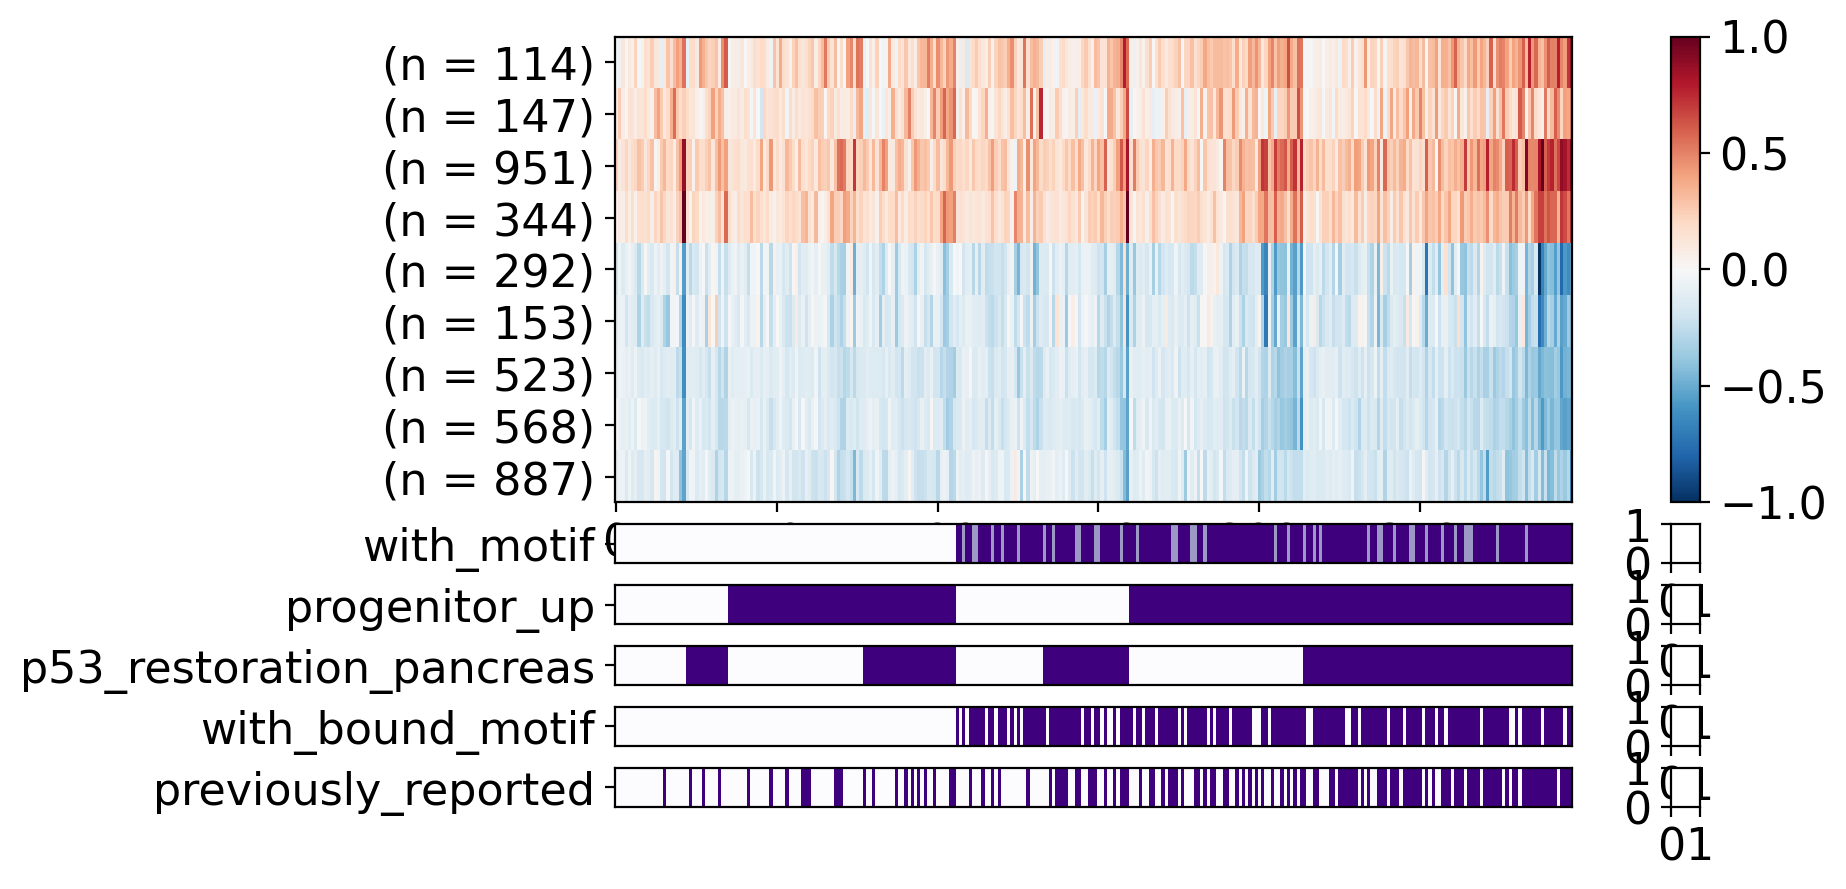

In [ ]:
yticklabels = adata_summary.obs_names.to_numpy()

f, ax = plt.subplots(6, 2, figsize = [7,5], gridspec_kw={'height_ratios': [3, 0.25, 0.25, 0.25, 0.25, 0.25], 'width_ratios': [5,0.15]})

im = ax[0][0].imshow(adata_summary.X, aspect='auto', interpolation = 'none', cmap = 'RdBu_r', vmin = -1, vmax = 1)
h = ax[0][0].set_yticks(range(len(yticklabels)), labels = [re.sub(".*\(", "(", x) for x in yticklabels])

cbar = f.colorbar(im, cax=ax[0][1])

selected_label = 'with_motif'
ax[1][0].imshow(adata_summary.var[selected_label].to_numpy()[:,None].T, aspect = 'auto', cmap='Purples')
ax[1][0].set_yticks([0], labels = [selected_label])
ax[1][0].set_xticks([])

selected_label = 'progenitor_up'
ax[2][0].imshow(adata_summary.var[selected_label].to_numpy()[:,None].T, aspect = 'auto', cmap='Purples')
ax[2][0].set_yticks([0], labels = [selected_label])
ax[2][0].set_xticks([])

selected_label = 'p53_restoration_pancreas'
ax[3][0].imshow(adata_summary.var[selected_label].to_numpy()[:,None].T, aspect = 'auto', cmap='Purples')
ax[3][0].set_yticks([0], labels = [selected_label])
ax[3][0].set_xticks([])

selected_label = 'with_bound_motif'
ax[4][0].imshow(adata_summary.var[selected_label].to_numpy()[:,None].T, aspect = 'auto', cmap='Purples')
ax[4][0].set_yticks([0], labels = [selected_label])
ax[4][0].set_xticks([])

selected_label = 'previously_reported'
ax[5][0].imshow(adata_summary.var[selected_label].to_numpy()[:,None].T, aspect = 'auto', cmap='Purples')
ax[5][0].set_yticks([0], labels = [selected_label])
ax[5][0].set_xticks([])

/data1/lowes/reyesj3/miniconda3/envs/scanpy/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2074: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in [*adata.obs_keys(), adata.obs.index.name]:


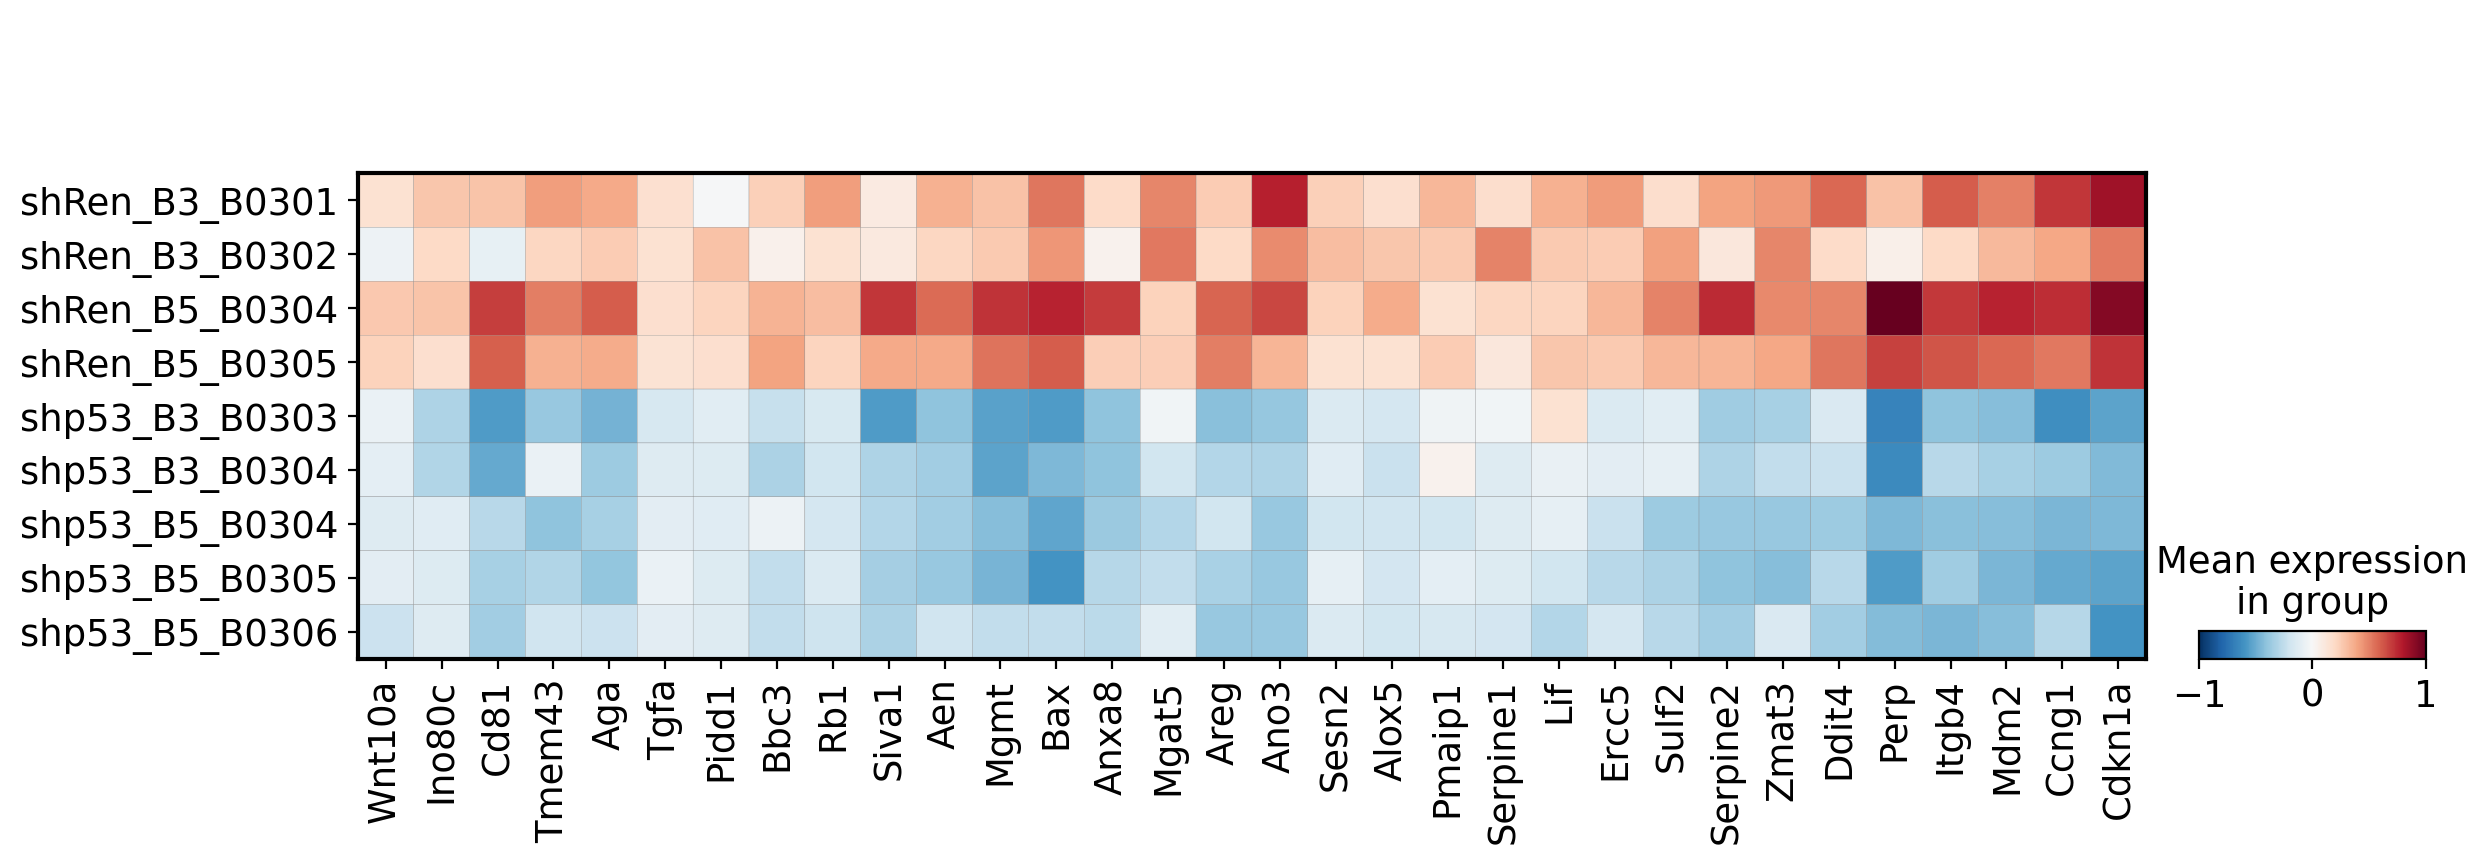

In [ ]:
representative_genes = ['MGAT5', 'TMEM43', 'ZMAT3', 'SULF2', 'MGMT', 'ERCC5', 'SESN2', 'DDIT4', 'PMAIP1', 'CCNG1', 'SIVA1', 'PIDD1', 'SERPINE1', 'SERPINE2', 'ALOX5', 'AREG', 'LIF', 'ANO3', 'AGA', 'ANXA8', 'NTPX1', 'CDKN1A', 'MDM2', 'BAX', 'BBC3', 'PMAIP1', 'PERP', 'ZMAT3', 'ITGB4', 'INO80C', 'RB1', 'WNT10A', 'CD81', 'AEN', 'TGFA']
adata_temp = adata_summary[:,ismember(adata_summary.var_names, representative_genes)[1]].copy()
adata_temp.var_names = [x.capitalize() for x in adata_temp.var_names]

ordering = np.argsort(adata_temp.var['previously_reported'].astype(np.uint8), kind = 'mergesort')
adata_temp = adata_temp[:,ordering].copy()
ordering = np.argsort(adata_temp.var['progenitor_up'].astype(np.uint8), kind = 'mergesort')
adata_temp = adata_temp[:,ordering].copy()
ordering = np.argsort(adata_temp.var['p53_restoration_pancreas'].astype(np.uint8), kind = 'mergesort')
adata_temp = adata_temp[:,ordering].copy()

sc.pl.matrixplot(adata_temp, groupby = ['genotype', 'batch', 'hash_id'], var_names = adata_temp.var_names, cmap = 'RdBu_r', vmin = -1, vmax = 1)


In [ ]:
import gseapy as gp
custom_signatures = {
    'lambert_p63_chip': lambert_p63_chip,
    'lambert_p63_gex': lambert_p63_gex,
    'lambert_p63_ITGB4hi': lambert_p63_ITGB4hi
}

In [ ]:
chea_p63 = gp.get_library("ChEA_2022")["P63 26484246 Chip-Seq KERATINOCYTES Human"]

In [ ]:
np.intersect1d(lambert_p63_chip, representative_genes)

array(['CDKN1A', 'ITGB4', 'LIF', 'MDM2'], dtype='<U13')

In [ ]:
np.intersect1d(representative_genes, chea_p63)

array(['AEN', 'ANXA8', 'BAX', 'BBC3', 'CD81', 'CDKN1A', 'DDIT4', 'INO80C',
       'ITGB4', 'MDM2', 'PERP', 'RB1', 'SERPINE1', 'SESN2', 'TGFA',
       'WNT10A'], dtype='<U13')

#### Stats on different groups of genes

In [ ]:
print("Total downregulated genes = " + str(adata_summary.n_vars))

Total downregulated genes = 298


Group 1 genes: 
- motif accessible in progenitor-like cells
- upregulated in progenitor-like cells
- upregulated upon p53 restoration

In [ ]:
motif_filter = adata_summary.var['with_motif'] > 0
progenitor_filter = adata_summary.var['progenitor_up']
restoration_filter = adata_summary.var['p53_restoration_pancreas']

valid_genes = (motif_filter) & (progenitor_filter) & (restoration_filter)
group1_genes = np.sort(adata_summary.var_names[valid_genes].to_numpy())

print("Total selected genes = " + str(len(group1_genes)))
print("Percent previously reported = " + str(np.mean(adata_summary.var['previously_reported'][valid_genes])))
print("Candidate new genes")
display(adata_summary[:,np.logical_and(np.logical_not(adata_summary.var['previously_reported']), valid_genes)].var_names.to_numpy())
print("With binding evidence = " + str(np.mean(adata_summary.var['with_bound_motif'][valid_genes])))

Total selected genes = 84
Percent previously reported = 0.7261904761904762
Candidate new genes


array(['TMEM184B', 'LBH', 'KDELR3', 'RAB40C', 'ABHD5', 'AIF1L', 'GALNT1',
       'CTC1', 'AAAS', 'PPARD', 'ACSBG1', 'CPPED1', 'SH3BGRL2', 'INF2',
       'PLEKHG3', 'CDC34', 'LZIC', 'ANXA8', 'PLEC', 'MGAT5', 'AREG',
       'NPTX1', 'ANO3'], dtype=object)

With binding evidence = 0.8095238095238095


Group 2 genes: 
- motif accessible in progenitor-like cells
- upregulated in progenitor-like cells
- not upregulated upon p53 restoration

In [ ]:
motif_filter = adata_summary.var['with_motif'] > 0
progenitor_filter = adata_summary.var['progenitor_up']
restoration_filter = np.logical_not(adata_summary.var['p53_restoration_pancreas'])

valid_genes = (motif_filter) & (progenitor_filter) & (restoration_filter)
group2_genes = np.sort(adata_summary.var_names[valid_genes].to_numpy())

print("Total selected genes = " + str(len(group2_genes)))
print("Percent previously reported = " + str(np.mean(adata_summary.var['previously_reported'][valid_genes])))
print("Candidate new genes")
display(adata_summary[:,np.logical_and(np.logical_not(adata_summary.var['previously_reported']), valid_genes)].var_names.to_numpy())
print("With binding evidence = " + str(np.mean(adata_summary.var['with_bound_motif'][valid_genes])))

Total selected genes = 54
Percent previously reported = 0.46296296296296297
Candidate new genes


array(['LGR6', 'GATM', 'ROBO3', 'KCNN3', 'ITPRIPL1', 'WNT10A', 'RASA4',
       'PLXNA1', 'HOMER3', 'HSPA5', 'CCDC122', 'RET', 'PSAPL1', 'TNIK',
       'TIAM1', 'GM13067', 'INO80C', 'DDIAS', 'PVT1', 'NUDCD2', 'ACSL3',
       'CALM1', 'GLRX3', 'ANTXR2', 'CD81', 'TMEM43', 'VPS36', 'AGA',
       'TMPRSS11E'], dtype=object)

With binding evidence = 0.7777777777777778


Group 3 genes: 
- motif accessible in progenitor-like cells
- not upregulated in progenitor-like cells
- upregulated upon p53 restoration

In [ ]:
motif_filter = adata_summary.var['with_motif'] > 0
progenitor_filter = np.logical_not(adata_summary.var['progenitor_up'])
restoration_filter = adata_summary.var['p53_restoration_pancreas']

valid_genes = (motif_filter) & (progenitor_filter) & (restoration_filter)
group3_genes = np.sort(adata_summary.var_names[valid_genes].to_numpy())

print("Total selected genes = " + str(len(group3_genes)))
print("Percent previously reported = " + str(np.mean(adata_summary.var['previously_reported'][valid_genes])))
print("Candidate new genes")
display(adata_summary[:,np.logical_and(np.logical_not(adata_summary.var['previously_reported']), valid_genes)].var_names.to_numpy())
print("With binding evidence = " + str(np.mean(adata_summary.var['with_bound_motif'][valid_genes])))

Total selected genes = 27
Percent previously reported = 0.5555555555555556
Candidate new genes


array(['CRYAB', 'IVL', 'RAC3', 'F8A', 'ATP6V1A', 'UBL3', 'SLC6A8', 'CANX',
       'SRP72', 'GADD45G', 'FRRS1', 'MAPK13'], dtype=object)

With binding evidence = 0.7407407407407407


Group 4 genes: 
- motif accessible in progenitor-like cells
- not upregulated in progenitor-like cells
- not upregulated upon p53 restoration

In [ ]:
motif_filter = adata_summary.var['with_motif'] > 0
progenitor_filter = np.logical_not(adata_summary.var['progenitor_up'])
restoration_filter = np.logical_not(adata_summary.var['p53_restoration_pancreas'])

valid_genes = (motif_filter) & (progenitor_filter) & (restoration_filter)
group4_genes = np.sort(adata_summary.var_names[valid_genes].to_numpy())

print("Total selected genes = " + str(len(group4_genes)))
print("Percent previously reported = " + str(np.mean(adata_summary.var['previously_reported'][valid_genes])))
print("Candidate new genes")
display(adata_summary[:,np.logical_and(np.logical_not(adata_summary.var['previously_reported']), valid_genes)].var_names.to_numpy())
print("With binding evidence = " + str(np.mean(adata_summary.var['with_bound_motif'][valid_genes])))

Total selected genes = 27
Percent previously reported = 0.18518518518518517
Candidate new genes


array(['FNDC10', 'CAPN5', 'GM13056', 'SLC35D1', 'NUBP1', 'NUAK2', 'VAMP2',
       'KRT20', 'GFER', 'CPOX', 'DGLUCY', 'GASK1B', 'TMEM238', 'MID1',
       'S100A14', 'H2AJ', 'EFHD2', 'TRP53COR1', 'RFX7', 'RPS19', 'NUCKS1',
       'MAP3K20'], dtype=object)

With binding evidence = 0.7407407407407407


Group 5 genes: 
- not motif accessible in progenitor-like cells
- upregulated in progenitor-like cells
- upregulated upon p53 restoration

In [ ]:
motif_filter = np.logical_not(adata_summary.var['with_motif'] > 0)
progenitor_filter = (adata_summary.var['progenitor_up'])
restoration_filter = (adata_summary.var['p53_restoration_pancreas'])

valid_genes = (motif_filter) & (progenitor_filter) & (restoration_filter)
group5_genes = np.sort(adata_summary.var_names[valid_genes].to_numpy())

print("Total selected genes = " + str(len(group5_genes)))
print("Percent previously reported = " + str(np.mean(adata_summary.var['previously_reported'][valid_genes])))
print("Candidate new genes")
display(adata_summary[:,np.logical_and(np.logical_not(adata_summary.var['previously_reported']), valid_genes)].var_names.to_numpy())
print("With binding evidence = " + str(np.mean(adata_summary.var['with_bound_motif'][valid_genes])))

Total selected genes = 29
Percent previously reported = 0.3448275862068966
Candidate new genes


array(['RAMP1', 'TDRD7', 'HK1', 'DYNLT3', 'PROCR', 'SPRR1A', 'IGSF9B',
       'TMTC3', 'NKX2-9', 'CAST', 'KIF1A', 'PARVB', 'NT5E', 'CELF5',
       'VEGFA', 'ENDOD1', 'LAMB3', 'CTLA2A', 'ATG9B'], dtype=object)

With binding evidence = 0.0


Group 6 genes: 
- not motif accessible in progenitor-like cells
- upregulated in progenitor-like cells
- not upregulated upon p53 restoration

In [ ]:
motif_filter = np.logical_not(adata_summary.var['with_motif'] > 0)
progenitor_filter = (adata_summary.var['progenitor_up'])
restoration_filter = np.logical_not(adata_summary.var['p53_restoration_pancreas'])

valid_genes = (motif_filter) & (progenitor_filter) & (restoration_filter)
group6_genes = np.sort(adata_summary.var_names[valid_genes].to_numpy())

print("Total selected genes = " + str(len(group6_genes)))
print("Percent previously reported = " + str(np.mean(adata_summary.var['previously_reported'][valid_genes])))
print("Candidate new genes")
display(adata_summary[:,np.logical_and(np.logical_not(adata_summary.var['previously_reported']), valid_genes)].var_names.to_numpy())
print("With binding evidence = " + str(np.mean(adata_summary.var['with_bound_motif'][valid_genes])))

Total selected genes = 42
Percent previously reported = 0.21428571428571427
Candidate new genes


array(['SHOX2', 'ZDHHC21', 'CERCAM', 'TMEM163', 'DSE', 'SLC37A2',
       'SH3KBP1', '9530059O14RIK', 'IRX3', 'LMO1', 'LRRC28', 'RRP36',
       'OLR1', 'AGTPBP1', 'DAPK2', 'RPS6KA4', 'CCDC88B', 'EEA1', 'IL23A',
       'MXI1', 'ENHO', 'SEMA7A', 'LHFPL2', 'SCN9A', 'IRX5', 'NECTIN1',
       'CTLA2B', '9530053A07RIK', 'SAMD12', 'AGAP1', 'FXYD5', 'REV1',
       'NGF'], dtype=object)

With binding evidence = 0.0


Group 7 genes: 
- not motif accessible in progenitor-like cells
- not upregulated in progenitor-like cells
- upregulated upon p53 restoration

In [ ]:
motif_filter = np.logical_not(adata_summary.var['with_motif'] > 0)
progenitor_filter = np.logical_not(adata_summary.var['progenitor_up'])
restoration_filter = (adata_summary.var['p53_restoration_pancreas'])

valid_genes = (motif_filter) & (progenitor_filter) & (restoration_filter)
group7_genes = np.sort(adata_summary.var_names[valid_genes].to_numpy())

print("Total selected genes = " + str(len(group7_genes)))
print("Percent previously reported = " + str(np.mean(adata_summary.var['previously_reported'][valid_genes])))
print("Candidate new genes")
display(adata_summary[:,np.logical_and(np.logical_not(adata_summary.var['previously_reported']), valid_genes)].var_names.to_numpy())
print("With binding evidence = " + str(np.mean(adata_summary.var['with_bound_motif'][valid_genes])))

Total selected genes = 13
Percent previously reported = 0.23076923076923078
Candidate new genes


array(['TCEA3', 'NACC2', 'ACVRL1', 'POGLUT1', 'GSTO1', 'ACBD5', 'NR3C1',
       'KIF5B', 'STOX2', 'CD55'], dtype=object)

With binding evidence = 0.0


In [ ]:
motif_filter = np.logical_not(adata_summary.var['with_motif'] > 0)
progenitor_filter = np.logical_not(adata_summary.var['progenitor_up'])
restoration_filter = np.logical_not(adata_summary.var['p53_restoration_pancreas'])

valid_genes = (motif_filter) & (progenitor_filter) & (restoration_filter)
group8_genes = np.sort(adata_summary.var_names[valid_genes].to_numpy())

print("Total selected genes = " + str(len(group8_genes)))
print("Percent previously reported = " + str(np.mean(adata_summary.var['previously_reported'][valid_genes])))
print("Candidate new genes")
display(adata_summary[:,np.logical_and(np.logical_not(adata_summary.var['previously_reported']), valid_genes)].var_names.to_numpy())
print("With binding evidence = " + str(np.mean(adata_summary.var['with_bound_motif'][valid_genes])))

Total selected genes = 22
Percent previously reported = 0.045454545454545456
Candidate new genes


array(['GPX3', 'LY6M', 'EEPD1', 'SEPTIN6', 'TC2N', 'FAM241B', 'SLC25A48',
       'SNAPC5', 'MID1IP1', 'UFL1', 'BTC', 'EREG', 'LRATD1', 'SLC9A2',
       'SCARB2', 'H1F0', 'GALNT7', 'H1F3', 'RXYLT1', 'H2-K1', 'ERDR1'],
      dtype=object)

With binding evidence = 0.0


### Enrichr analysis CheaA 2022

In [ ]:
gene_sets = [adata_summary.var_names.to_numpy(), group1_genes, group2_genes, group3_genes, group4_genes, group5_genes, group6_genes, group7_genes, group8_genes]

result = []
for my_geneset in gene_sets:
    enr = gp.enrichr(list(my_geneset), "ChEA_2022", organism = 'mouse', cutoff = 1).res2d
    enr.index = enr['Term']
    temp = enr.loc[["TP53 23651856 ChIP-Seq MEFs Mouse", "P63 26484246 Chip-Seq KERATINOCYTES Human"],"Adjusted P-value"].to_list()
    enr = gp.enrichr(list(my_geneset), custom_signatures, organism = 'mouse', cutoff = 1).res2d
    enr.index = enr['Term']
    if "lambert_p63_chip" in enr.index:
        temp = temp + list(enr.loc[["lambert_p63_chip"],"Adjusted P-value"].to_list())
    else:
        temp = temp + [1]
    result.append(temp)

In [ ]:
df = pd.DataFrame(result)
df = -np.log10(df)

In [ ]:
df.columns = ["TP53 23651856 ChIP-Seq MEFs Mouse", "P63 26484246 ChIP-Seq KERATINOCYTES Human", "lambert_p63_chip"]

In [ ]:
import seaborn as sns

<Axes: >

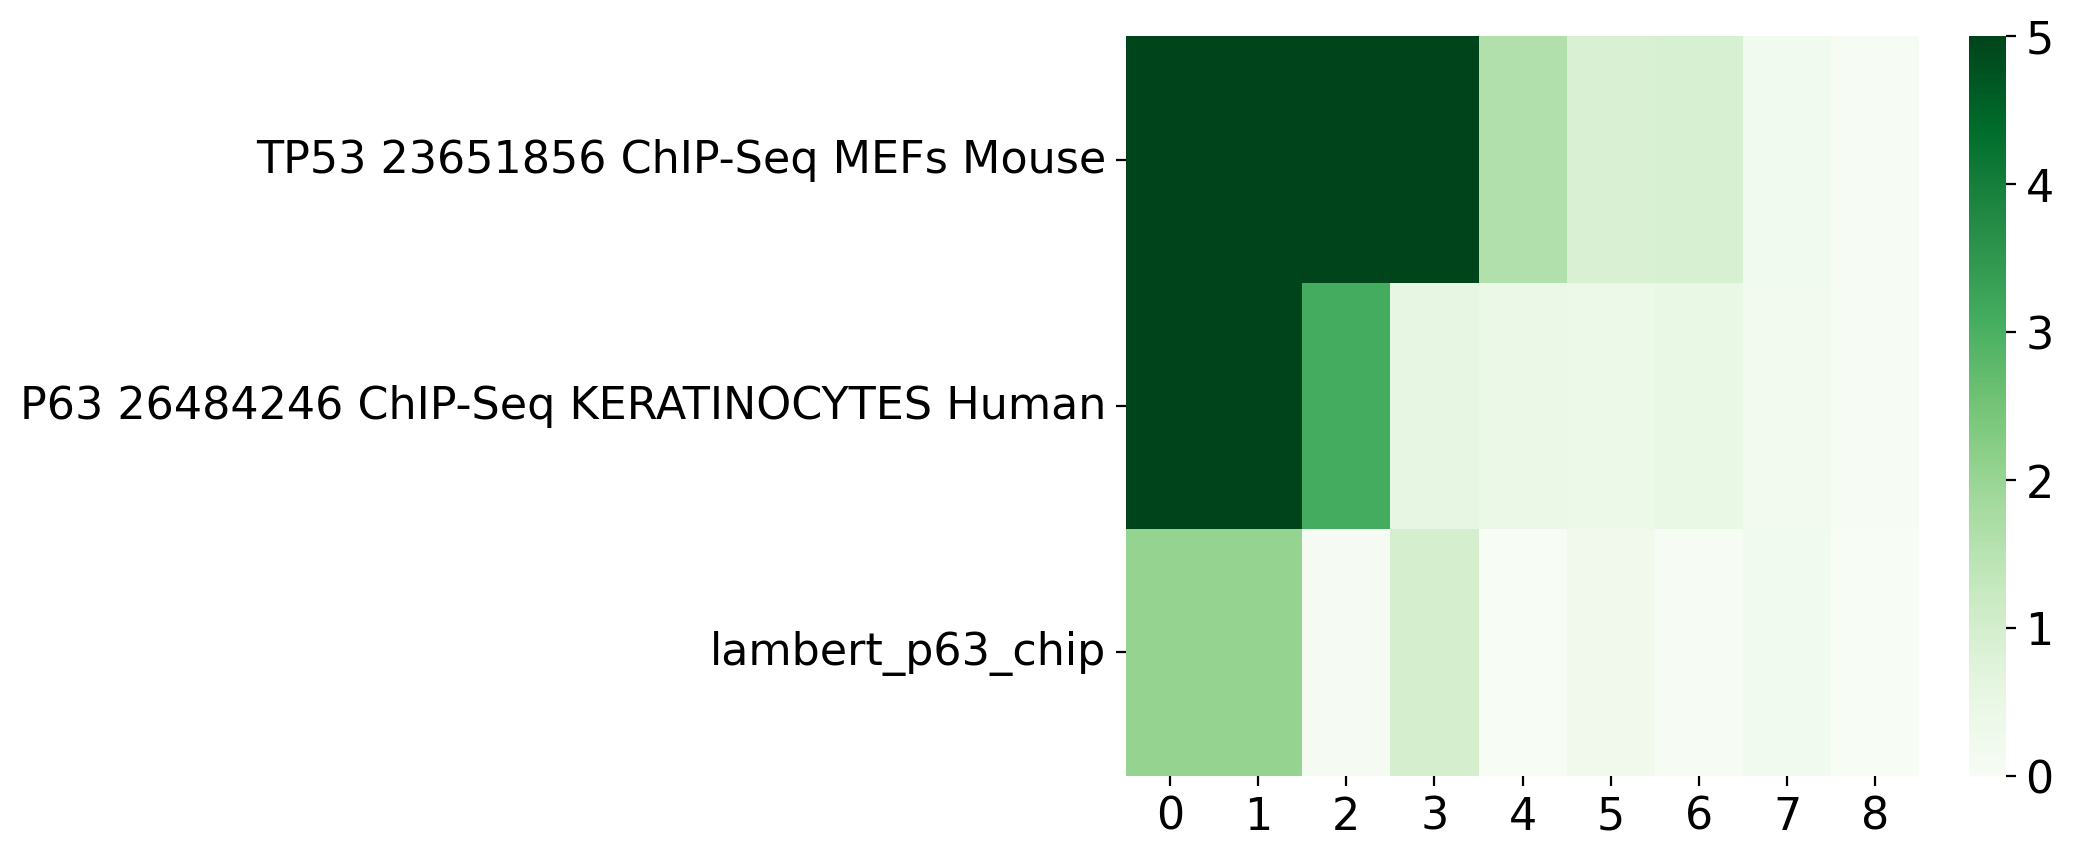

In [ ]:
sns.heatmap(df.T, vmax = 5, cmap = 'Greens')

### Enrichr analysis GO

In [ ]:
def plot_enrichr_result(temp, save_filename = None):
    plt.figure(figsize = [4, 0.25*temp.shape[0]])
    temp['logp'] = -np.log(temp['Adjusted P-value'])/np.log(10)
    temp['rank'] = list(range(temp.shape[0]))
    sns.barplot(x = 'logp', y = 'Term', data = temp)
    for i in range(temp.shape[0]):
        current_term = temp.index[i]
        plt.text(0, i, ', '.join([x.capitalize() for x in re.split(";", temp['Genes'][current_term])]))
    plt.xlim([0,3])
    if save_filename is not None:
        plt.savefig(save_filename)
        temp.to_csv(re.sub(".pdf", ".csv", save_filename))

In [ ]:
gp.get_library_name()
selected_library = 'KEGG_2019_Mouse'
selected_library = 'KEGG_2021_Human'
selected_library = 'GO_Biological_Process_2025'
selected_library = 'MSigDB_Hallmark_2020'
selected_library = 'Panther_2016'
selected_library = 'Reactome_Pathways_2024'

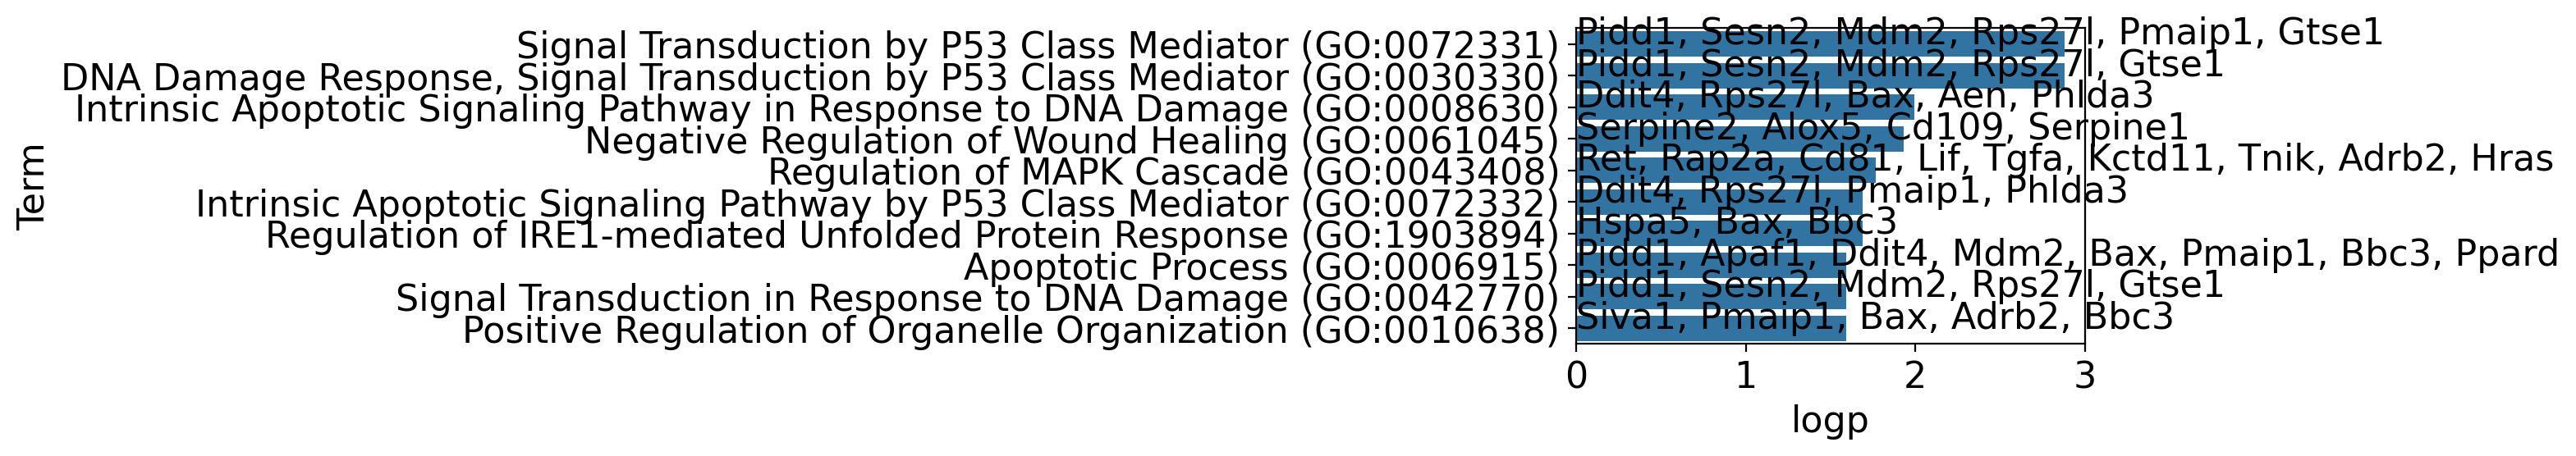

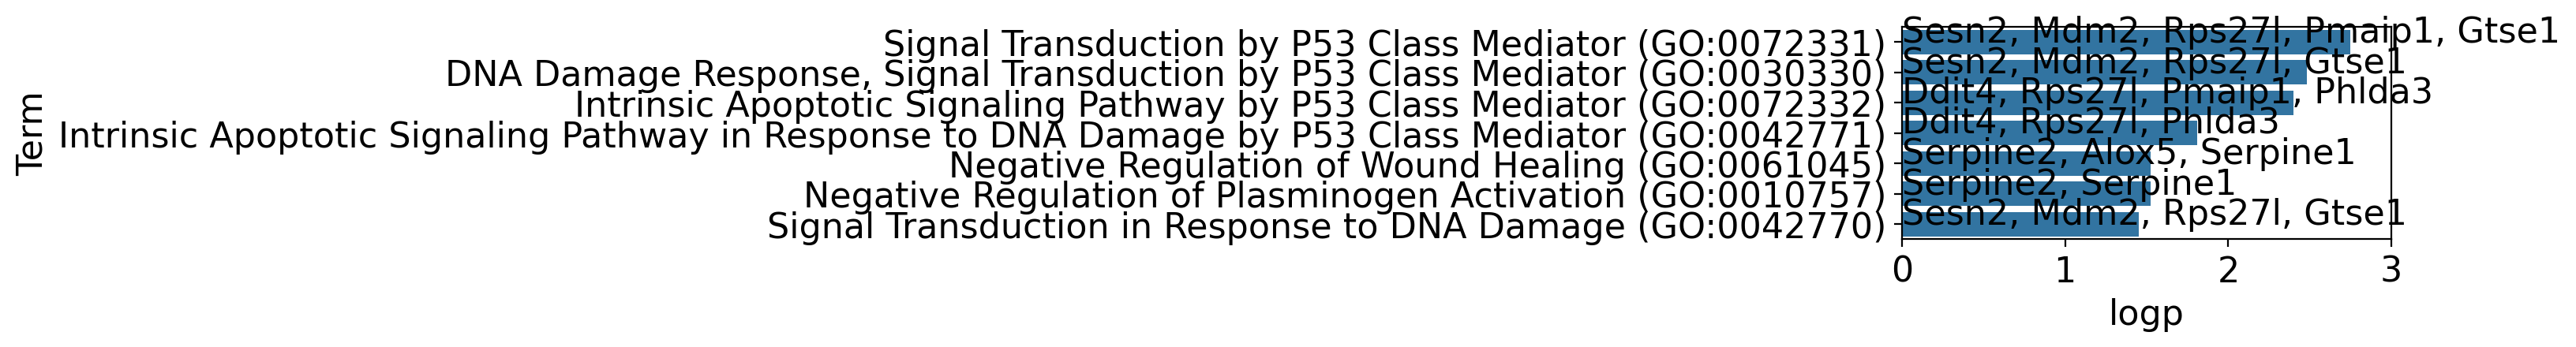

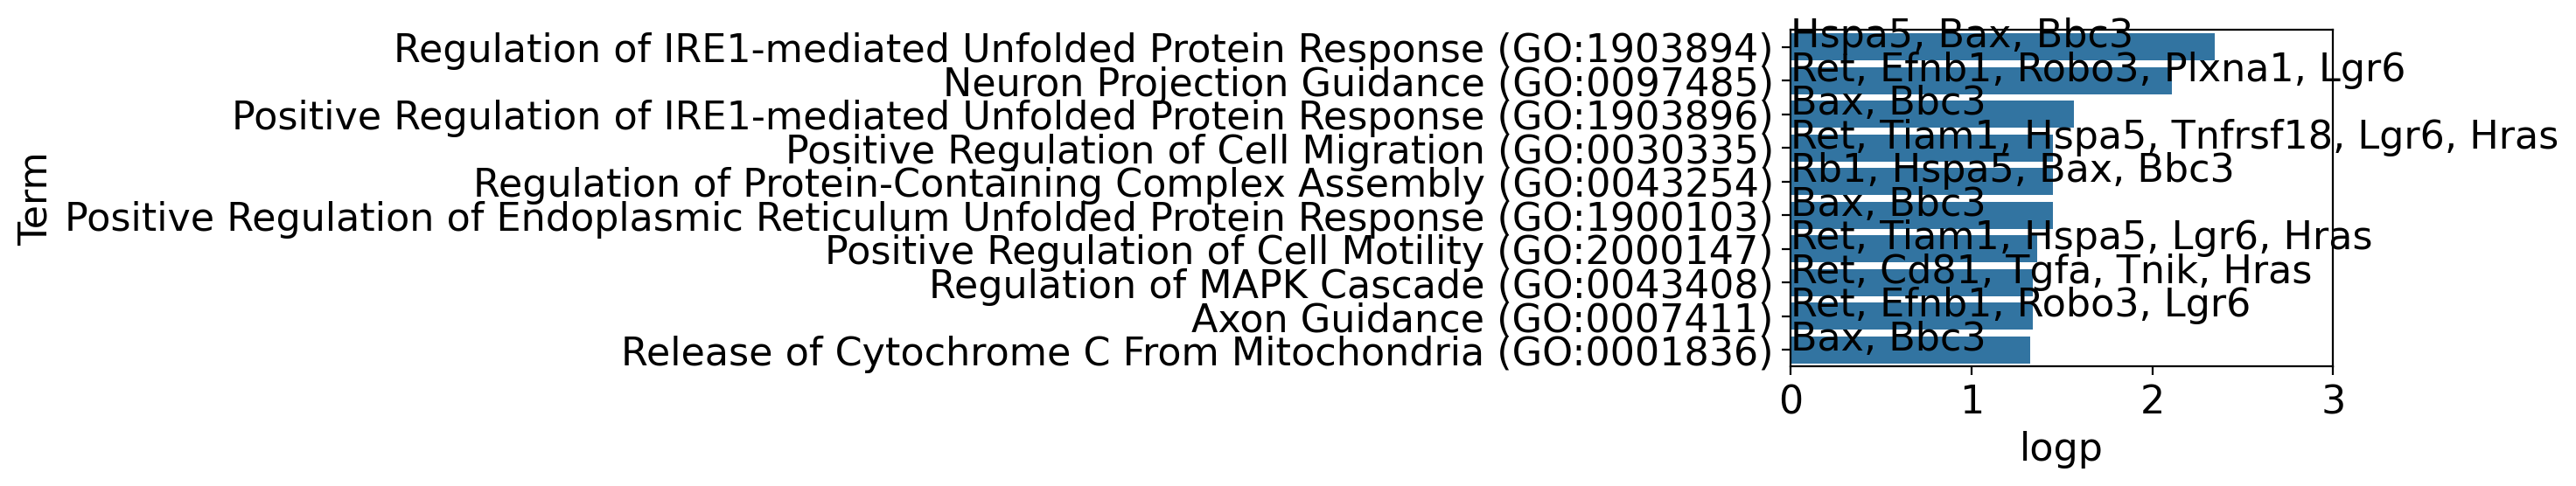

In [ ]:
selected_library = 'GO_Biological_Process_2025'
gene_sets = [list(group1_genes) + list(group2_genes), group1_genes, group2_genes]

result = []
for i, my_geneset in enumerate(gene_sets):
    enr = gp.enrichr(list(my_geneset), selected_library, organism = 'mouse', cutoff = 1).res2d
    enr.index = enr['Term']
    temp = enr.loc[enr['Adjusted P-value'] < 0.05,:].copy()
    temp = temp.iloc[:(np.min([10, temp.shape[0]])),:].copy()
    plot_enrichr_result(temp)
    result.append(temp)

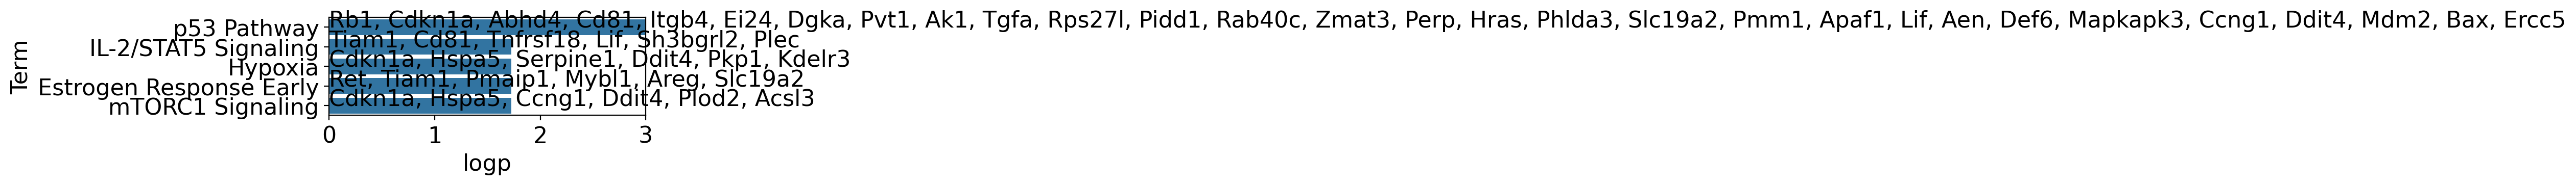

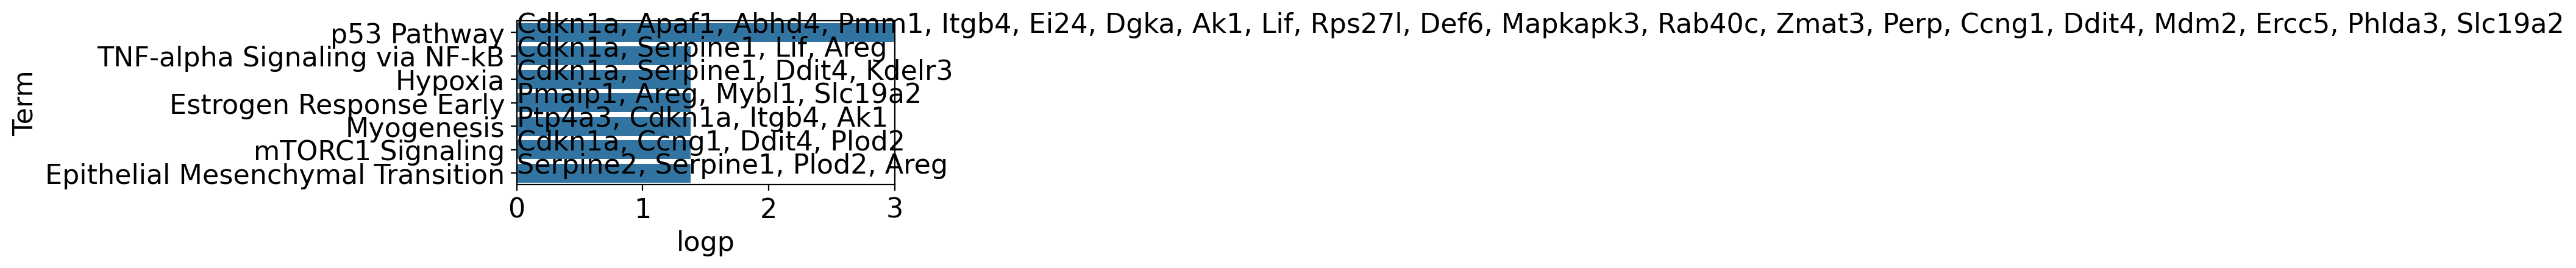

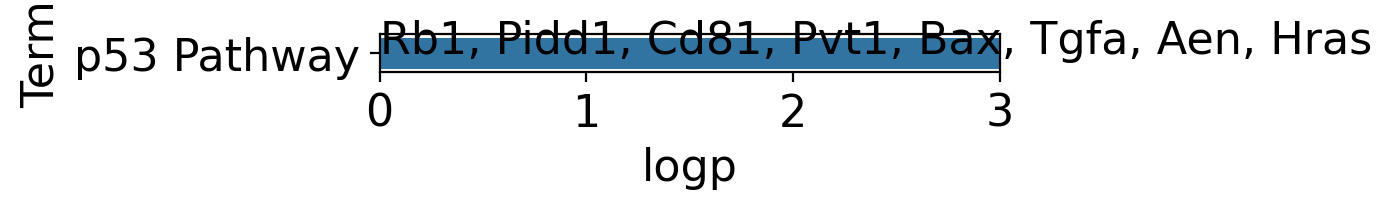

In [ ]:
selected_library = 'MSigDB_Hallmark_2020'
gene_sets = [list(group1_genes) + list(group2_genes), group1_genes, group2_genes]

result = []
for i, my_geneset in enumerate(gene_sets):
    enr = gp.enrichr(list(my_geneset), selected_library, organism = 'mouse', cutoff = 1).res2d
    enr.index = enr['Term']
    temp = enr.loc[enr['Adjusted P-value'] < 0.05,:].copy()
    temp = temp.iloc[:(np.min([10, temp.shape[0]])),:].copy()
    plot_enrichr_result(temp)
    result.append(temp)